In [6]:
# Import everything required
import re
import nltk
import spacy
import time
import emoji
import pandas as pd
from joblib import dump, load
from nltk.corpus import stopwords
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV as GCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, r2_score

In [7]:
# Setup Resources
nltk.download('punkt_tab')
nltk.download('stopwords')

# Load spaCy with only the lemmatizer enabled for speed
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "tokenizer"])
negation_words = {'not', 'no', 'never', 'neither', 'nor', 'none', 'n\'t', 'nt', 'barely', 'hardly'}
stop_words = set(stopwords.words('english')) - negation_words # Preserve negation words 

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\97797\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\97797\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# Load amazon dataset
amazon_df = pd.read_csv("datasets/amazon_training.csv")
print(amazon_df.head())
print(amazon_df.info())
print(amazon_df.count())
print(amazon_df.isnull().sum())

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

In [9]:
# Data Cleaning for amazon dataset

# Unwanted noise removal 
amazon_df = amazon_df.drop(columns = ['Id', 'ProductId', 'UserId', 'ProfileName', 'Time']) 

# Dropping reviews with low public interaction
amazon_df = amazon_df.drop(amazon_df[amazon_df['HelpfulnessDenominator']<5].index) 

# Drop rows with null values in 'Summary' column
amazon_df.dropna(inplace=True) 

# Remove rows with invalid "Score" or "HelpfulnessNumerator"
amazon_df.drop(amazon_df[(amazon_df['Score'] > 5) | (amazon_df['Score'] < 0)].index, inplace=True)
amazon_df.drop(amazon_df[amazon_df['HelpfulnessNumerator'] > amazon_df['HelpfulnessDenominator']].index, inplace=True)

# Only keep ratio of "HelpfulnessNumerator" by "HelpfulnessDenominator" that provide insights on both rather than keeping both of them
# This creates a single ratio that describes how much positive review of the total i.e ~1 means ~100% helpful review while ~0 meand ~0% helpful review 
amazon_df['HelpfulnessRatio'] = amazon_df['HelpfulnessNumerator']/amazon_df['HelpfulnessDenominator']
amazon_df.drop(columns = ['HelpfulnessDenominator', 'HelpfulnessNumerator'], inplace=True)

# Now drop rows where many people interacted with a review but very few found it helpful
amazon_df = amazon_df[amazon_df['HelpfulnessRatio']>=0.3]

print(amazon_df.isnull().sum(), end='\n\n..............................................................................\n\n')
print(amazon_df.info(), end='\n\n..............................................................................\n\n')
amazon_df.head()

Score               0
Summary             0
Text                0
HelpfulnessRatio    0
dtype: int64

..............................................................................

<class 'pandas.core.frame.DataFrame'>
Index: 59730 entries, 14 to 568436
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Score             59730 non-null  int64  
 1   Summary           59730 non-null  object 
 2   Text              59730 non-null  object 
 3   HelpfulnessRatio  59730 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB
None

..............................................................................



,Score,Summary,Text,HelpfulnessRatio
14,5,Strawberry Twizzlers - Yummy,The Strawberry Twizzlers are my guilty pleasur...,0.8
15,5,"Lots of twizzlers, just what you expect.",My daughter loves twizzlers and this shipment ...,0.8
32,4,Best of the Instant Oatmeals,McCann's Instant Oatmeal is great if you must ...,1.0
33,4,Good Instant,This is a good instant oatmeal from the best o...,1.0
34,5,Great Irish oatmeal for those in a hurry!,Instant oatmeal can become soggy the minute th...,1.0


In [10]:
HelpfulnessRatio = amazon_df['HelpfulnessRatio']

# Drop all feature other than "Summary" and "Text". Since we only need text as input for sentiment prediction
amazon_df.drop(columns=['HelpfulnessRatio'], inplace=True)

# Combine Summary and Text to process as one. It reduces computation time and combines word weight of both "Summary" and "Text"
amazon_df['Combined_Content'] = amazon_df['Summary'].fillna('') + " " + amazon_df['Text'].fillna('')

# Drop both "Summary" and "Text"
amazon_df.drop(columns=['Summary', 'Text'], inplace=True)
amazon_df

,Score,Combined_Content
14,5,Strawberry Twizzlers - Yummy The Strawberry Tw...
15,5,"Lots of twizzlers, just what you expect. My da..."
32,4,Best of the Instant Oatmeals McCann's Instant ...
33,4,Good Instant This is a good instant oatmeal fr...
34,5,Great Irish oatmeal for those in a hurry! Inst...
...,...,...
568388,4,Awesome product I have used agave for many thi...
568405,5,Arrived Fine The product arrived pretty quickl...
568407,5,Premium Edge Dry Cat Food for Kitten My 6 mont...
568423,5,"Good purchase I bought this candy for my son, ..."


In [11]:
# Preprocessing :
# Whitespace Normalization -> Lowercasing -> Tokenization -> Stop-word Removal -> Lemmatization

# Define a dictionary of common Twitter slang
slang_dict = {
    "lol": "laughing out loud",
    "idk": "i do not know",
    "smh": "shaking my head",
    "brb": "be right back",
    "omg": "oh my god",
    "rt": "retweet",
    "u": "you",
    "r": "are",
    "bday": "birthday"
}
# Slang translator
def translate_slang(text):
    words = text.split()
    # Replace the word if it exists in our dictionary, otherwise keep the word
    new_words = [slang_dict[w] if w in slang_dict else w for w in words]
    return " ".join(new_words)
    
# Define a Lightweight NLTK Cleaning Function
def clean_and_tokenize(raw_text):
    """Performs basic NLTK cleaning before spaCy lemmatization."""
    if not isinstance(raw_text, str):
        return ""

    # Remove unnecessary whitespaces and make it lowercase.
    text = (" ".join(raw_text.split())).lower()

    # Url remover
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove words like "soooooooooooooooo" that contains more than two times of repeating letter in a word
    text = re.sub(r'(.)\1+', r'\1\1', text)

    # Remove emojis
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Translate slang into proper words
    text = translate_slang(text)
    
    # Convert sentence into tokens
    tokens = nltk.word_tokenize(text)

    # Return only alphabetic words
    return " ".join([w for w in tokens if w not in stop_words])

# Define a Function for Optimized spaCy Lemmatization using nlp.pipe (Batching)
def clean_and_lemmatize(raw_texts, batch_size:int=1000):
    """Performs lemmatization over cleaned texts(from 'clean_and_tokenize' function)."""
    
    # Now when testing, we can directly utilize this function for cleaning and lemmatizing rather than performing it manually.
    
    final_preprocessed = []
    
    if isinstance(raw_texts, str):
        raw_texts = [raw_texts]
        
    raw_cleaned_texts = [clean_and_tokenize(t) for t in raw_texts]
    
    for doc in nlp.pipe(raw_cleaned_texts, batch_size=1000):
        final_preprocessed.append(" ".join([token.lemma_ for token in doc]))
        
    return final_preprocessed

# Define a Function to Convert Score into three classes
def convert_score(score):
    if isinstance(score, int):
        if score < 3:
            return -1
        elif score > 3:
            return 1
        else:
            return 0
    else:
        if score == 'positive':
            return -1
        elif score == 'negative':
            return -1
        else:
            return 0
        
# Process the Data
print(f"Starting processing for {len(amazon_df)} rows...")
start_time = time.time()

amazon_df['Cleaned_Text'] = clean_and_lemmatize(amazon_df['Combined_Content'])

# Call the score converting function
amazon_df['Score'] = [convert_score(s) for s in amazon_df['Score']]

# Cleanup and Save
# Drop the intermediate column to save memory
amazon_df.drop(columns=['Combined_Content'], inplace=True)
amazon_df = amazon_df.dropna()

end_time = time.time()
print(f"Finished! Total time: {(end_time - start_time) / 60:.2f} minutes")

# save the dataframe so that we don't have to re-preprocess the data since it takes very long time
amazon_df.to_csv('cleaned_amazon_data.csv', index=False)
print(f"'cleaned_amazon_data.csv' saved successfully!!")


Starting processing for 59730 rows...
Finished! Total time: 12.13 minutes
'cleaned_amazon_data.csv' saved successfully!!


In [12]:
# Review Result
cleaned_data = pd.read_csv("datasets/cleaned_amazon_data.csv")
cleaned_data = cleaned_data.dropna()
cleaned_data

,Score,Cleaned_Text
0,1,strawberry twizzler - yummy strawberry twizzle...
1,1,"lot twizzler , expect . daughter love twizzler..."
2,1,good instant oatmeal mccann 's instant oatmeal...
3,1,good instant good instant oatmeal good oatmeal...
4,1,great irish oatmeal hurry ! instant oatmeal be...
...,...,...
59725,1,awesome product use agave many thing find well...
59726,1,arrive fine product arrive pretty quickly easy...
59727,1,premium edge dry cat food kitten 6 month old m...
59728,1,"good purchase buy candy son , spend time franc..."


In [13]:
negative = cleaned_data[cleaned_data['Score']==-1]
neutral = cleaned_data[cleaned_data['Score']==0]
positive = cleaned_data[cleaned_data['Score']==1]

print(f"Negative count:{len(negative)} \nNeutral count:{len(neutral)} \nPositive count:{len(positive)}")

Negative count:15896 
Neutral count:4657 
Positive count:39177


In [17]:
# 1. Initialize the Vectorizer with key parameters
tfidf = TfidfVectorizer(
    lowercase=True,      # Converts all text to lowercase
    ngram_range=(1, 2),  # Captures single words and pairs (e.g., "not good")
    max_features=5000    # Limits the output to the 5,000 most important words
)

# 2. Fit and transform cleaned_data using the tf-idf vectorizer
X = tfidf.fit_transform(cleaned_data['Cleaned_Text'])

# 3. Define target
y = cleaned_data['Score']

""" Since the dataset is imbalanced, we use smote to look at the "Neutral" reviews in our TF-IDF matrix 
and creates new, fake data points that are mathematically located between existing ones. """
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-Test split (80-20)
X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,random_state=42,test_size = 0.2,stratify=y_resampled)

print(f"Train-Test splitted successfully !!")

Train-Test splitted successfully !!


In [18]:
# Training SVM

# As out dataset is of size 60,000 rows, LinearSVC is generally preferred over
# standard SVC because it scales much better to large feature sets created by TF-IDF.

param_grid_linear = {
    'C': [0.2, 0.5, 0.75, 1, 5],
    'loss': ['hinge', 'squared_hinge'],
    'max_iter': [10000], 
    'class_weight':['balanced', None]
}

linear_svc = LinearSVC(random_state=42)

# We use f1_macro to ensure the model performs well across all 3 classes (Pos/Neg/Neu)
grid_search_svm = GCV(
    linear_svc, 
    param_grid_linear, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1, 
    verbose=2
)

print("Starting Grid Search for SVM ...")
start_time = time.time()

grid_search_svm.fit(X_train, y_train)

print(f"Best LinearSVC Params: {grid_search_svm.best_params_}")
best_svm = grid_search_svm.best_estimator_

# Predict and Evaluate
y_pred_svm = best_svm.predict(X_test)
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Neutral', 'Positive']))

end_time = time.time()
print(f"\n\n Finished! Total time: {(end_time - start_time) / 60:.2f} minutes")

Starting Grid Search for SVM ...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best LinearSVC Params: {'C': 5, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 10000}

SVM Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90      7835
     Neutral       0.87      0.91      0.89      7836
    Positive       0.91      0.87      0.89      7836

    accuracy                           0.89     23507
   macro avg       0.89      0.89      0.89     23507
weighted avg       0.89      0.89      0.89     23507



 Finished! Total time: 28.22 minutes


In [19]:
# alpha is the smoothing parameter. 
# Smaller alpha (e.g., 0.1) allows the model to be more sensitive to specific words.
param_grid_nb = {
    'alpha': [1.32, 1.33, 1.34, 1.35],
    'fit_prior': [True, False],  # Whether to learn class prior probabilities or not
    'class_prior': [
        None,
        [0.33, 0.33, 0.34],
        [0.4, 0.4, 0.2]
    ]
}

nb = MultinomialNB()

# We use f1_macro to ensure the model performs well across all 3 classes (Pos/Neg/Neu)
grid_search_nb = GCV(
    estimator=nb, 
    param_grid=param_grid_nb, 
    cv=5, 
    scoring='f1_macro', 
    verbose=1, 
    n_jobs=-1
)

print("Starting Grid Search for Naive Bayes...")
start_time = time.time()
grid_search_nb.fit(X_train, y_train)

print(f"Best Parameters for NB: {grid_search_nb.best_params_}")
best_nb = grid_search_nb.best_estimator_

# Predict and Evaluate
y_pred_nb = best_nb.predict(X_test)
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Neutral', 'Positive']))

end_time = time.time()
print(f"\n\n Finished! Total time: {(end_time - start_time) / 60:.2f} minutes")

Starting Grid Search for Naive Bayes...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters for NB: {'alpha': 1.32, 'class_prior': None, 'fit_prior': False}

Naive Bayes Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.72      0.75      7835
     Neutral       0.70      0.76      0.73      7836
    Positive       0.81      0.81      0.81      7836

    accuracy                           0.76     23507
   macro avg       0.77      0.76      0.76     23507
weighted avg       0.77      0.76      0.76     23507



 Finished! Total time: 0.06 minutes


In [20]:
# Saving models and tf-idf vectorization so we don't have to retrain again
dump(best_svm,'sentiment_detection_svm_model_v7.pkl')
dump(best_nb,'sentiment_detection_nb_model_v7.pkl')
dump(tfidf, 'tfidf_vectorizer_v7.pkl')

['tfidf_vectorizer_v7.pkl']

In [23]:
# Load the models
import joblib
best_nb = load('Models/sentiment_detection_nb_model_v7(best_acc_single).pkl')
best_svm =load('Models/sentiment_detection_svm_model_v7(best_acc_single).pkl')
tfidf = load('Models/tfidf_vectorizer_v7(best_acc_single).pkl')

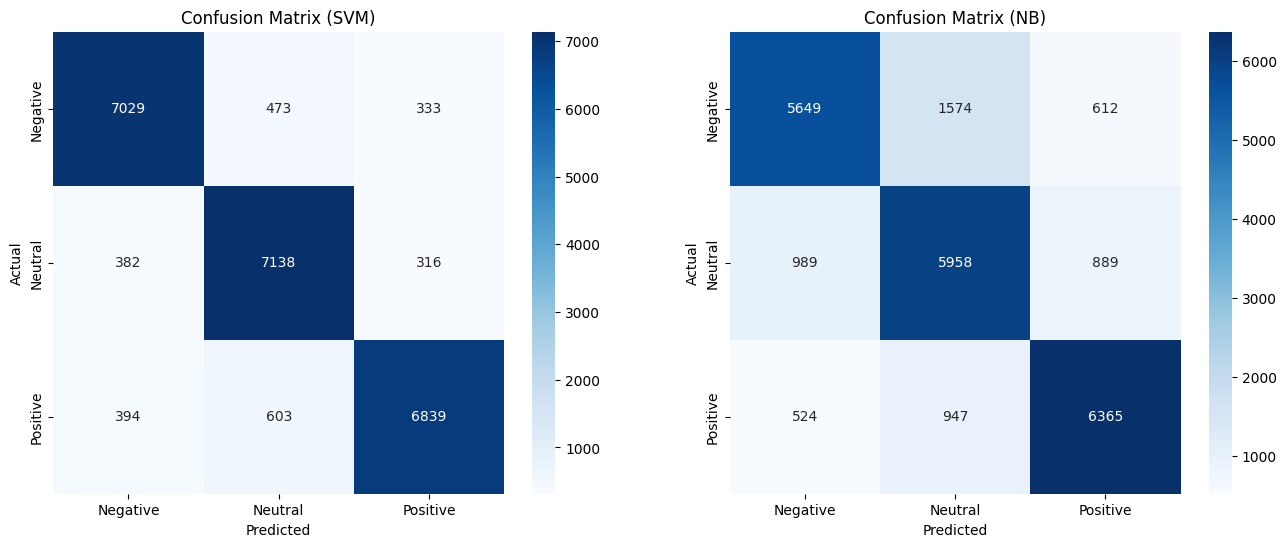

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_svm = best_svm.predict(X_test)
y_pred_nb = best_nb.predict(X_test)

# Generate the confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plotting
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (SVM)')

plt.subplot(1,2,2)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (NB)')

plt.show()


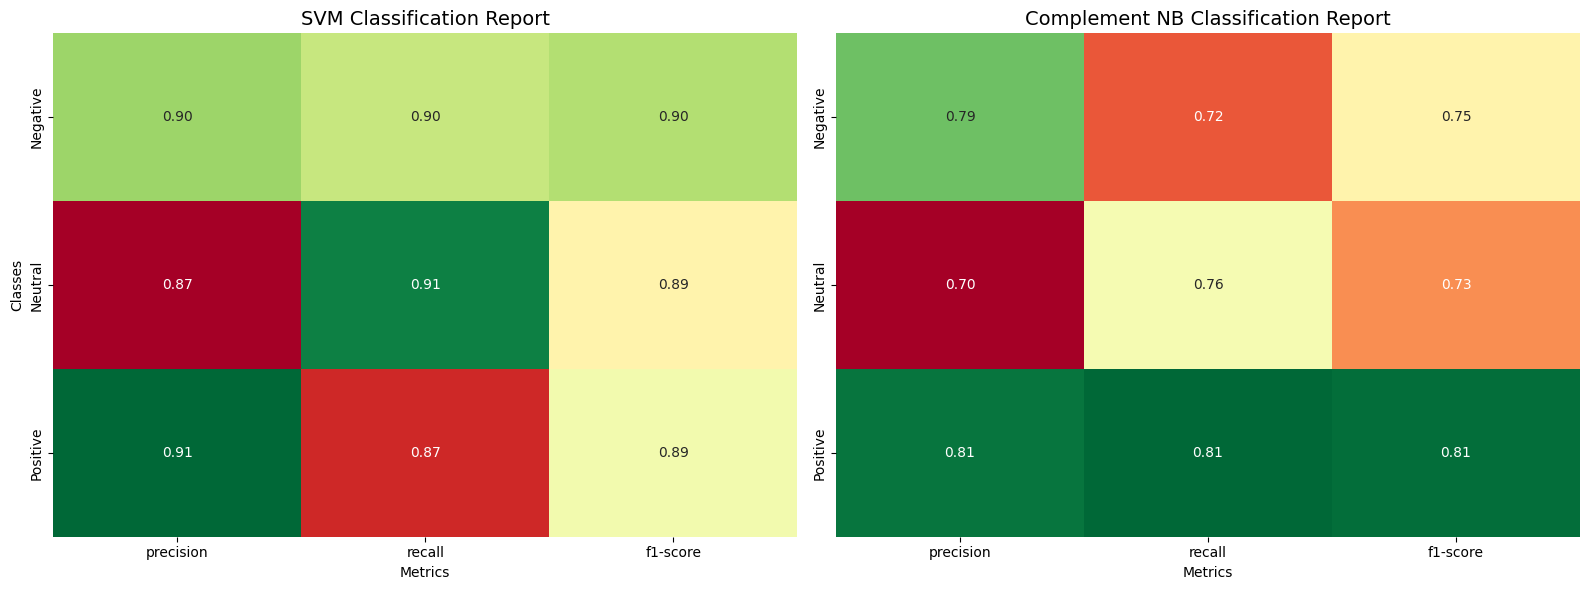

In [25]:
# 1. Generate Dictionary Reports
report_svm = classification_report(y_test, y_pred_svm, 
                                  target_names=['Negative', 'Neutral', 'Positive'], 
                                  output_dict=True)
report_nb = classification_report(y_test, y_pred_nb, 
                                 target_names=['Negative', 'Neutral', 'Positive'], 
                                 output_dict=True)

# 2. Convert to DataFrames (Keep only individual classes)
df_svm = pd.DataFrame(report_svm).iloc[:-1, :3].T
df_nb = pd.DataFrame(report_nb).iloc[:-1, :3].T

# 3. Plotting
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df_svm, annot=True, cmap='RdYlGn', ax=ax[0], fmt=".2f", cbar=False)
ax[0].set_title('SVM Classification Report', fontsize=14)
ax[0].set_xlabel('Metrics')
ax[0].set_ylabel('Classes')

sns.heatmap(df_nb, annot=True, cmap='RdYlGn', ax=ax[1], fmt=".2f", cbar=False)
ax[1].set_title('Complement NB Classification Report', fontsize=14)
ax[1].set_xlabel('Metrics')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()


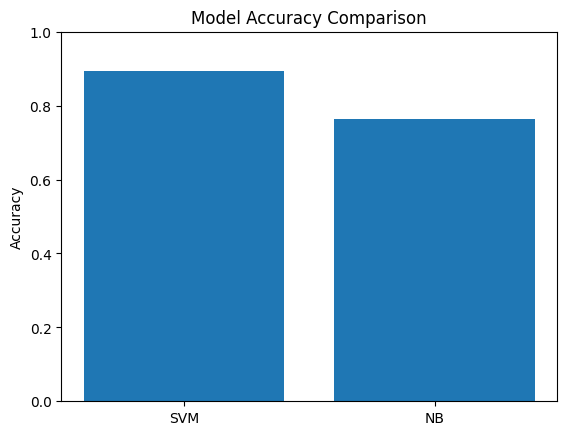

In [26]:
svm_acc = pd.DataFrame(report_svm).iloc[1,4]
nb_acc = pd.DataFrame(report_nb).iloc[1,4]
plt.bar(["SVM", "NB"], [svm_acc, nb_acc])

plt.ylim(0, 1.0)

plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()